## Методические указания по выполнению лабораторной работы №3

**Тема: Обнаружение объектов с использованием Faster R-CNN**

**Цель работы:** Ознакомиться с архитектурой Faster R-CNN и принципами двухэтапного обнаружения объектов.

**Задачи:**
- **Здесь важно не просто запустить, а именно исследовать различные параметры и обосновать их выбор**
- Изучить теоретические основы двухэтапного обнаружения объектов: роль RPN и классификационного этапа в Faster R-CNN.
- Загрузить предобученную модель Faster R-CNN.
- Ознакомиться с форматом аннотаций для обучения в задаче детекции.
- Визуализировать предсказания, проанализировать ошибки модели и провести исследование по поиску баланса FN/FP.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Faster R-CNN](https://arxiv.org/pdf/1506.01497), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новым форматом данных для обучения нейро-сетевых моделей детекции. Для оценки модели воспользуемся набором данных [Pascal VOC 2007](http://host.robots.ox.ac.uk/pascal/VOC/).

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/master/models/faster_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Архитектура Faster R-CNN

Существует два основных подхода к обнаружению объектов:
Двухстадийные модели – более точные, но медленные.
Одностадийные модели – быстрые, но менее точные.

Faster R-CNN — это двухэтапная модель детекции объектов. В отличие от ResNeXt, Faster R-CNN не просто классифицирует изображение, а находит на нём несколько объектов, предсказывает bounding boxes и присваивает метки классам. Она состоит из следующих компонентов:

1. Backbone (ResNet/VGG/MobileNet) – извлекает признаки из изображения.
2. Region Proposal Network (RPN) – предлагает области, где могут находиться объекты.
3. ROI Pooling + Fully Connected Layers – классифицирует объекты и уточняет bounding boxes.
4. Non-Maximum Suppression (NMS) – убирает дублирующиеся предсказания.


В предыдущих лабораторных работах мы познакомились с классификацией изображений, где модель предсказывает единственный класс для всего изображения. Однако во многих задачах компьютерного зрения классификация недостаточна. Например, когда на одном изображении присутствуют несколько объектов разных классов необходимо не только определить, что изображено, но и где это находится.

Faster R-CNN –  модель, которая также решает задачу обнаружения объектов, добавляя к классификации локализацию.

#### 1.2 Формат данных для задачи детекции

Faster R-CNN требует разметки изображений, помимо классов включающей в себя и координаты bounding box по оси x, y.
Ознакомьтесь с форматом набора данных Pascal VOC, скачайте аннотации набора данных и изучите структуру **.xml** файлов в папке Annotations по [ссылке](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtestnoimgs_06-Nov-2007.tar).

#### 1.3 Оценка качества

Помимо известных вам инструментов оценить качество работы детектора могут помочь:

Confidence Score - значение, указывающее на уверенность модели в том, что на данном месте изображения находится объект. Модель предсказывает этот параметр для каждого предсказанного bounding box. Чем выше confidence score, тем более уверена модель в своём предсказании.

Фильтрация предсказаний - модель может предсказать много объектов, но не все из них будут точными. Чтобы уменьшить количество ложных срабатываний (False Positives), применяется фильтр предсказаний, используя confidence threshold. Если confidence score меньше заданного порога - предсказание отбрасывается.


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

In [1]:
# импорт пакетов
import torch
import torchvision.models.detection as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np


#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [2]:
# импорт модели
model = models.fasterrcnn_resnet50_fpn(weights="DEFAULT")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()
device

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 165MB/s]


'cuda'

#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель. Он понадобится позже для преобразования изображений при прямом проходе через модель чтобы получить предсказания:

In [3]:
# загрузка датасета

test_dataset = datasets.VOCDetection(root="http://host.robots.ox.ac.uk/pascal/VOC", year="2007", image_set="test", download=True)

100%|██████████| 451M/451M [00:31<00:00, 14.5MB/s]


In [4]:
print(test_dataset[0])

(<PIL.Image.Image image mode=RGB size=353x500 at 0x7C08FF8CD210>, {'annotation': {'folder': 'VOC2007', 'filename': '000001.jpg', 'source': {'database': 'The VOC2007 Database', 'annotation': 'PASCAL VOC2007', 'image': 'flickr', 'flickrid': '341012865'}, 'owner': {'flickrid': 'Fried Camels', 'name': 'Jinky the Fruit Bat'}, 'size': {'width': '353', 'height': '500', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'dog', 'pose': 'Left', 'truncated': '1', 'difficult': '0', 'bndbox': {'xmin': '48', 'ymin': '240', 'xmax': '195', 'ymax': '371'}}, {'name': 'person', 'pose': 'Left', 'truncated': '1', 'difficult': '0', 'bndbox': {'xmin': '8', 'ymin': '12', 'xmax': '352', 'ymax': '498'}}]}})


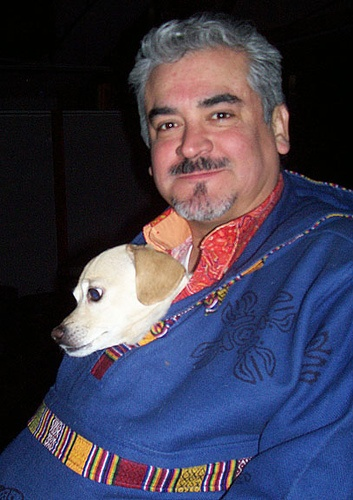

In [5]:
test_dataset[0][0]

#### 2.4 Объявление методов для работы с данными

Далее необходимо создать методы препроцессинга: метод чтения файла аннотации для возврата numpy-объекта содержащего bounding boxes, и метод отрисовки истиных и прогнозных bounding boxes на изображении для визуализации полученных результатов.

In [6]:
from PIL import Image, ImageDraw
import xml.etree.ElementTree as ET

def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin, ymin, xmax, ymax = (int(bbox.find("xmin").text), int(bbox.find("ymin").text),
                                  int(bbox.find("xmax").text), int(bbox.find("ymax").text))
        boxes.append([xmin, ymin, xmax, ymax])
    return np.array(boxes)

def draw_predictions(image, boxes, labels, scores, color="blue"):
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores): #zip allows iteration through multiple iter. objects
        xmin, ymin, xmax, ymax = map(int, box) #map applies function on iter. objects
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=2)
        draw.text((xmin, ymin), f"{label} ({score:.2f})", fill=color)
    return image

#### 2.5 Анализ False Positives / False Negatives

Для измерения того, насколько хорошо bounding box предсказан, применяется параметр IoU (Intersection over Union) между двумя bounding boxes. Чем он выше, тем точнее предсказание. Для его оценки опишем следующий метод, принимающий два np.array-объекта (прогнозные и истинные координаты):

In [7]:
def calculate_iou(pred_box, gt_box):
    x1, y1, x2, y2 = map(int, pred_box)
    x1g, y1g, x2g, y2g = map(int, gt_box)

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

#### 2.6 Оценка модели и визуализация результатов

Выполните прямой проход нескольких изображений через модель. Для этого необходимо загрузить изображения и аннотации, применить преобразование изображений в тензор. Затем получите выходы модели:

In [8]:
voc_classes = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa',
    'train', 'tvmonitor'
]

coco_classes = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
    'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]


coco_to_voc =  {
    "motorcycle" : "motorbike",
    "airplane" : "aeroplane",
    "couch" : "sofa",
    "potted plant" : "pottedplant",
    "dining table" : "diningtable",
    "tv" : "tvmonitor"
}


['person'] pred labels Blue
['dog', 'person'] real labels Red


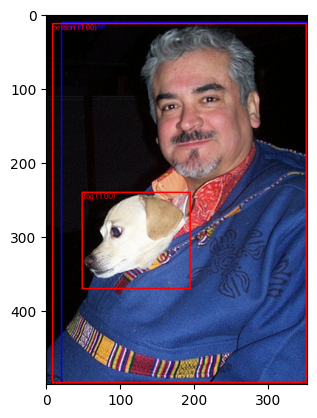


False Positive:  0 False Negative:  1
['train' 'person'] pred labels Blue
['train'] real labels Red


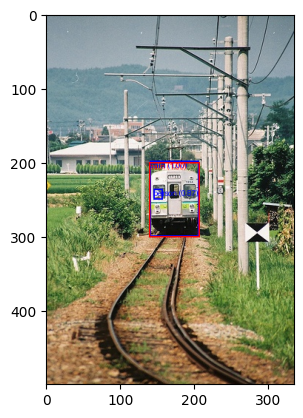



False Positive:  1 False Negative:  0
['chair'] pred labels Blue
['sofa', 'chair'] real labels Red


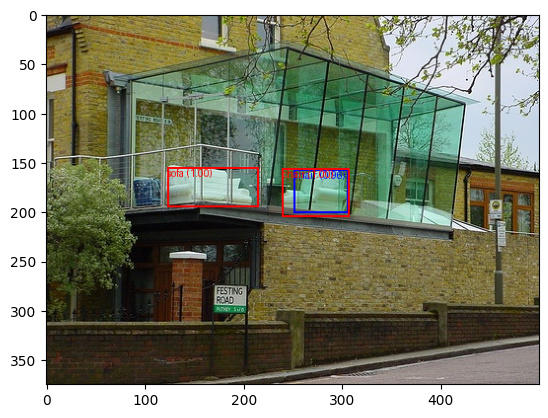


False Positive:  0 False Negative:  1
['car' 'car' 'car' 'car' 'car' 'car' 'car' 'car' 'car'] pred labels Blue
['car', 'car', 'car', 'car', 'car', 'car', 'car'] real labels Red


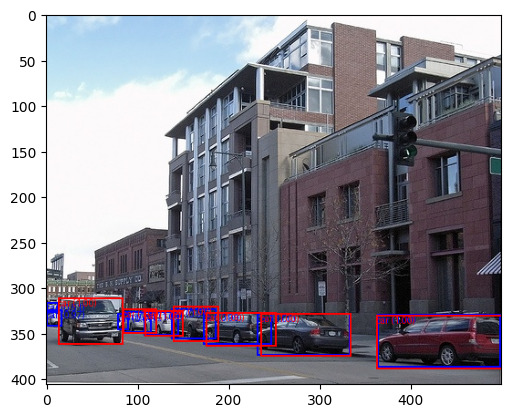










False Positive:  3 False Negative:  1
['chair' 'chair' 'chair' 'chair' 'diningtable' 'pottedplant' 'chair'
 'chair' 'chair' 'pottedplant' 'chair' 'diningtable'] pred labels Blue
['pottedplant', 'diningtable', 'chair', 'chair', 'chair', 'chair', 'chair', 'chair'] real labels Red


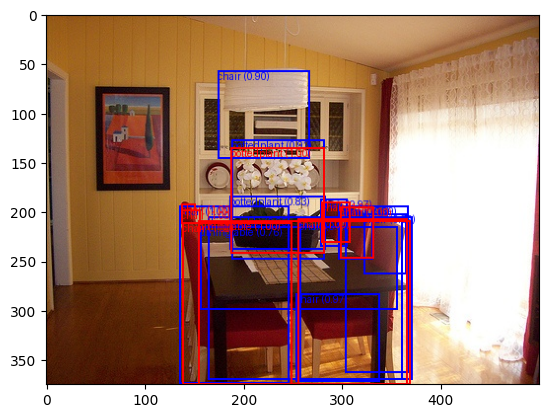













False Positive:  5 False Negative:  2
['chair' 'sofa' 'diningtable' 'chair' 'chair'] pred labels Blue
['chair'] real labels Red


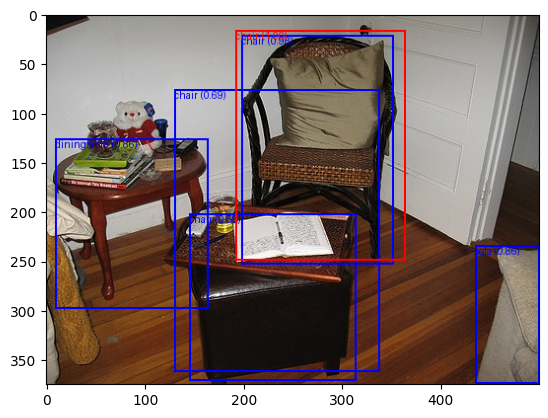






False Positive:  4 False Negative:  0
['person' 'horse' 'person'] pred labels Blue
['horse', 'person'] real labels Red


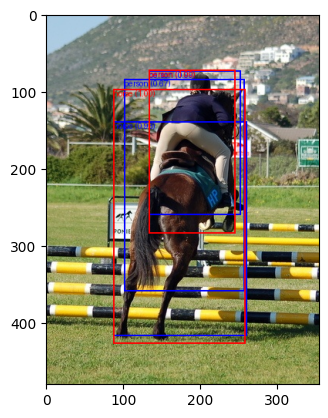




False Positive:  0 False Negative:  0
['cat' 'cat' 'cat'] pred labels Blue
['cat'] real labels Red


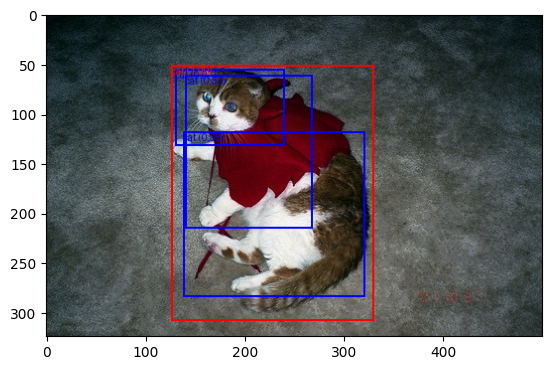




False Positive:  2 False Negative:  0
['cow'] pred labels Blue
['cow'] real labels Red


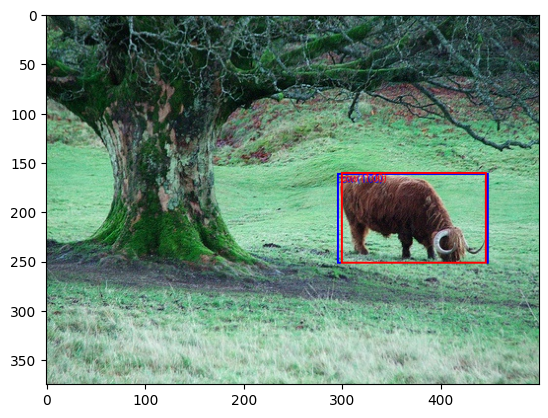


False Positive:  0 False Negative:  0
['car' 'car' 'car' 'bus' 'person' 'tvmonitor' 'person' 'person' 'person'
 'car' 'car' 'person' 'car' 'motorbike' 'bottle'] pred labels Blue
['bus', 'car', 'car', 'person', 'person', 'person', 'car'] real labels Red


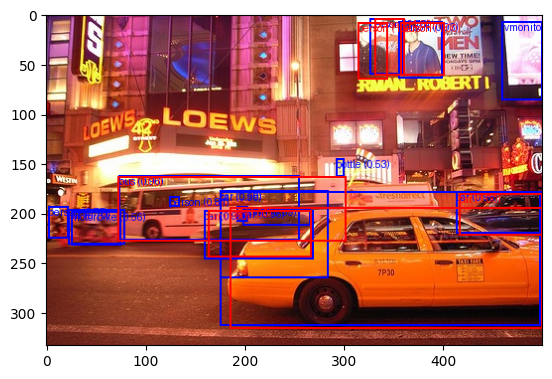
















False Positive:  9 False Negative:  1


In [52]:
# выберите N изображений 5 из датасета
confidence_threshold = 0.5
for i in range(10):
  img = transforms.ToTensor()(test_dataset[i][0]).to(device)
  with torch.no_grad():
    outputs = model([img])
    pred_scores = outputs[0]['scores'].cpu().numpy()
    good_indexes = [i for i in range(len(pred_scores)) if pred_scores[i] >= confidence_threshold]

    pred_boxes = np.take(outputs[0]['boxes'].cpu().numpy(), good_indexes, axis=0)

    pred_labels = np.take(outputs[0]['labels'].cpu().numpy(), good_indexes)
    pred_labels = np.array([coco_classes[index] for index in pred_labels])

    pred_scores = np.take(pred_scores, good_indexes)

    real_boxes = []
    real_labels = []
    real_scores = []

    for elem in test_dataset[i][1]["annotation"]["object"]:
      bnd_box = elem["bndbox"]
      real_boxes.append([bnd_box["xmin"], bnd_box["ymin"], bnd_box["xmax"], bnd_box["ymax"]])
      real_labels.append(elem["name"])
      real_scores.append(1)

    delete_labels_index = []
    for j in range(len(pred_labels)):
      if pred_labels[j] not in voc_classes:
        if pred_labels[j] in coco_to_voc:
          pred_labels[j] = coco_to_voc[pred_labels[j]]
        else:
          delete_labels_index.append(j)

    pred_labels = np.delete(pred_labels, delete_labels_index)
    pred_boxes = np.delete(pred_boxes, delete_labels_index, axis=0)
    pred_scores = np.delete(pred_scores, delete_labels_index)

    print(pred_labels, "pred labels", "Blue")
    print(real_labels, "real labels", "Red")


    pred_img = draw_predictions(test_dataset[i][0], pred_boxes, pred_labels, pred_scores)
    pred_img = draw_predictions(pred_img, real_boxes, real_labels, real_scores, color='red')
    plt.imshow(np.asarray(pred_img))
    plt.show()
    # вычислите IoU для выбранных изображений

    fp = 0 # модель предсказала объект, но его нет в gt
    fn = 0 # модель не обнаружила объект, но он есть в gt
    iou_threshold = 0.5

    for box in pred_boxes:
      print()
      iou = max([calculate_iou(box, gt_box) for gt_box in real_boxes])
      if iou < iou_threshold:
        fp += 1

    for box in real_boxes:
      iou = max([calculate_iou(box, gt_box) for gt_box in pred_boxes])
      if iou < iou_threshold:
        fn += 1
    print("False Positive: ", fp, "False Negative: ", fn)
    print("=========================================")
    # подсчитайте количество False Positive и False Negative для выбранных изображений

#### 2.7 Поиск оптимальной конфигурации

Проанализируйте полученные результаты с выбранным значением фильтрации предсказаний. Проведите исследование с целью поиска оптимального порога и баланса FN/FP. Обоснуйте полученные результаты:

In [23]:
fn_fp_data = []

In [24]:
# исследование
iou_conf = [0.5]
confidence_conf = [0.5, 0.7, 0.8, 0.9, 0.95]

for iou_threshold in iou_conf:
  for confidence_threshold in confidence_conf:
    temp_data = []
    for i in range(10):
      img = transforms.ToTensor()(test_dataset[i][0])[None, :, :, :].to(device)
      with torch.no_grad():
        outputs = model(img)
        pred_scores = outputs[0]['scores'].cpu().numpy()
        good_indexes = [i for i in range(len(pred_scores)) if pred_scores[i] >= confidence_threshold]

        pred_boxes = np.take(outputs[0]['boxes'].cpu().numpy(), good_indexes, axis=0)

        pred_labels = np.take(outputs[0]['labels'].cpu().numpy(), good_indexes)
        pred_labels = np.array([coco_classes[index] for index in pred_labels])

        pred_scores = np.take(pred_scores, good_indexes)

        real_boxes = []
        real_labels = []
        real_scores = []

        for elem in test_dataset[i][1]["annotation"]["object"]:
          bnd_box = elem["bndbox"]
          real_boxes.append([bnd_box["xmin"], bnd_box["ymin"], bnd_box["xmax"], bnd_box["ymax"]])
          real_labels.append(elem["name"])
          real_scores.append(1)

        delete_labels_index = []
        for j in range(len(pred_labels)):
          if pred_labels[j] not in voc_classes:
            if pred_labels[j] in coco_to_voc:
              pred_labels[j] = coco_to_voc[pred_labels[j]]
            else:
              delete_labels_index.append(j)

        pred_labels = np.delete(pred_labels, delete_labels_index)
        pred_boxes = np.delete(pred_boxes, delete_labels_index, axis=0)
        pred_scores = np.delete(pred_scores, delete_labels_index)

        fp = 0 # модель предсказала объект, но его нет в gt
        fn = 0 # модель не обнаружила объект, но он есть в gt

        for box in pred_boxes:
          print()
          iou = max([calculate_iou(box, gt_box) for gt_box in real_boxes])
          if iou < iou_threshold:
            fp += 1

        for box in real_boxes:
          iou = max([calculate_iou(box, gt_box) for gt_box in pred_boxes])
          if iou < iou_threshold:
            fn += 1
        print("Conf threshold = ", confidence_threshold, " IoU threshold = ", iou_threshold)
        print("False Positive: ", fp, "False Negative: ", fn)
        print("=========================================")
        temp_data.append((fn, fp))
    fn_fp_data.append(temp_data)



Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  0 False Negative:  1


Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  1 False Negative:  0

Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  0 False Negative:  1









Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  3 False Negative:  1












Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  5 False Negative:  2





Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  4 False Negative:  0



Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  0 False Negative:  0



Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  2 False Negative:  0

Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  0 False Negative:  0















Conf threshold =  0.5  IoU threshold =  0.5
False Positive:  9 False Negative:  1

Conf threshold =  0.7  IoU threshold =  0.5
False Positive:  0 False Negative:  1


Conf threshold =  0.7  IoU threshold =  0.5

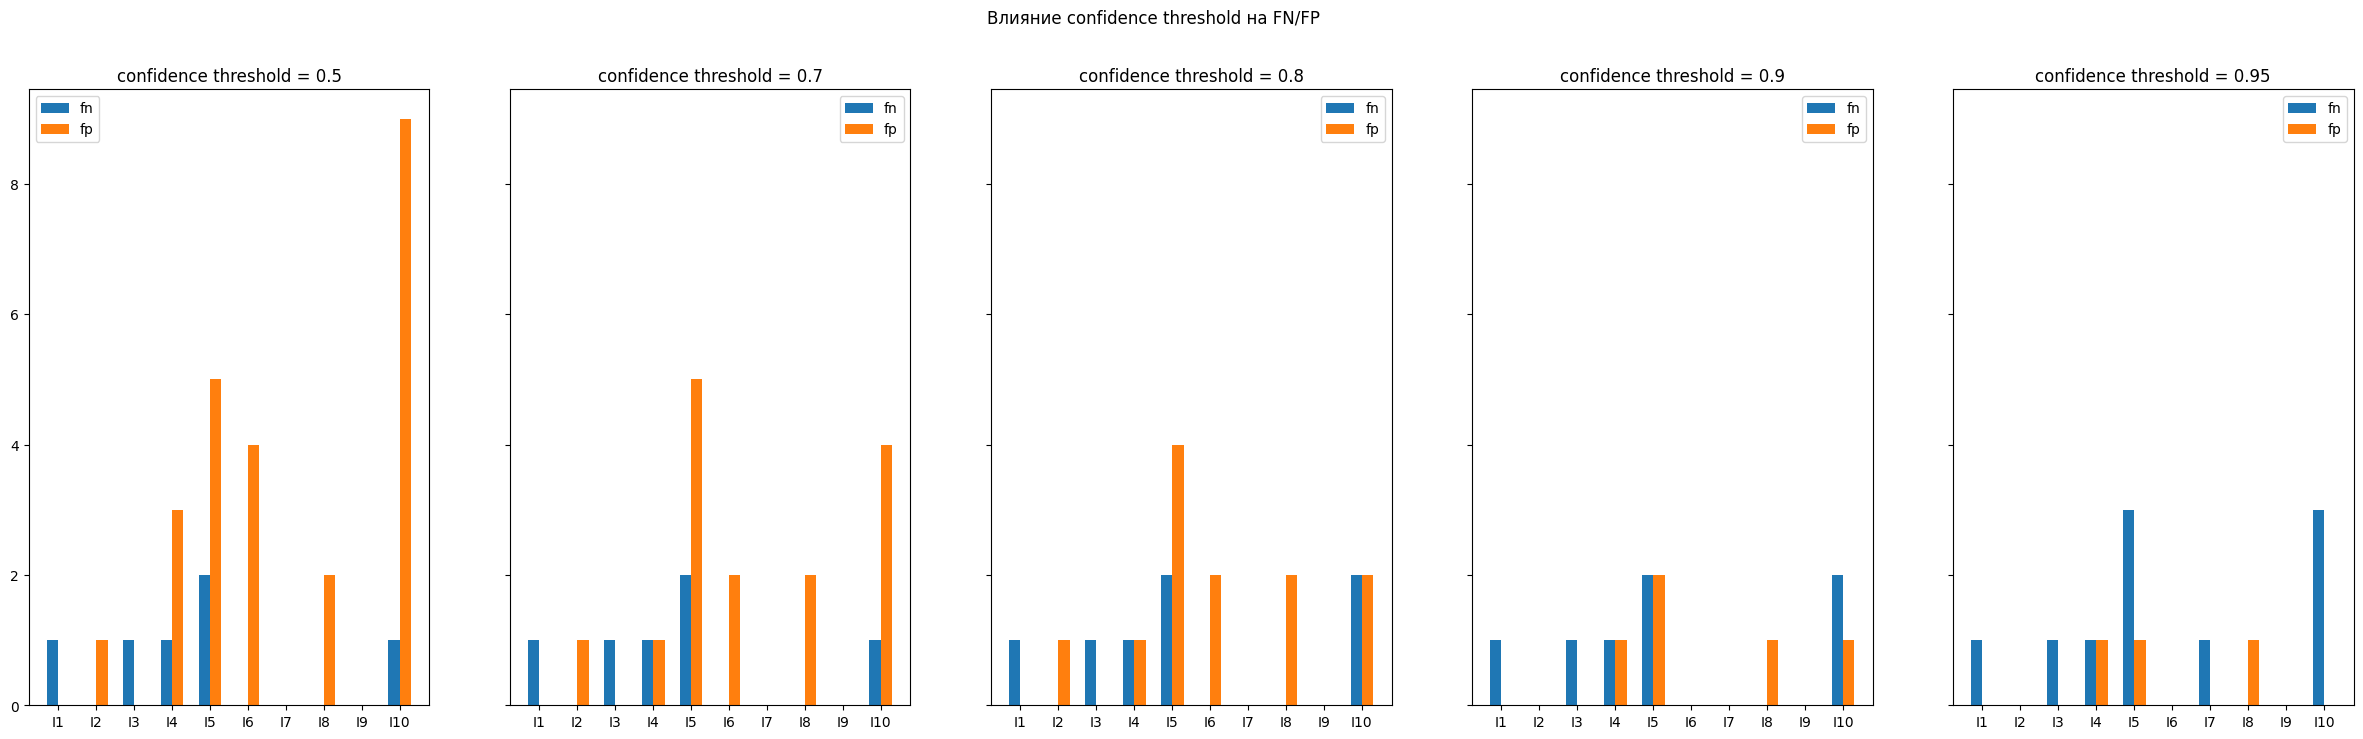

In [51]:
j = 0
figure, axis = plt.subplots(1, len(confidence_conf), squeeze=False, figsize=(30, 8), sharey=True)
figure.suptitle("Влияние confidence threshold на FN/FP")
for k in range(len(confidence_conf)):
  cat_par = [f"I{i}" for i in range(1, 11)]
  fn = [elem[0] for elem in fn_fp_data[k]]
  fp = [elem[1] for elem in fn_fp_data[k]]
  width = 0.3
  x = np.arange(len(cat_par))
  rects1 = axis[0][k].bar(x - width/2, fn, width, label="fn")
  rects2 = axis[0][k].bar(x + width/2, fp, width, label="fp")
  axis[0][k].set_xticks(x)
  axis[0][k].set_xticklabels(cat_par)
  axis[0][k].set_title(f"confidence threshold = {confidence_conf[k]}")
  axis[0][k].legend()